# KmerDPVAE: Uncertainty-Aware Genome Clustering

This notebook implements and evaluates a k-mer-based VAE with a truncated Dirichlet Process Gaussian Mixture Model (DP-GMM) prior for unsupervised genome clustering with uncertainty estimation.

**Pipeline:**
0. **Contrastive pretraining**: Train encoder (256→512→16) on paired reads from `train_2m.csv` using Bernoulli contrastive loss with negative thresholding.
1. **Warm-up**: Freeze encoder, train decoder + variance head with $p(z) = \mathcal{N}(0, I)$ prior and KL annealing.
2. **Mixture init**: Run k-means on encoder means $\mu_i$ to initialize the DP-GMM components.
3. **Joint training**: Minimize the negative ELBO with closed-form mixture updates and Bhattacharyya overlap penalty.
4. **Evaluation**: Assess clustering quality on `reference/binning_5.tsv` (37,278 sequences, 323 species).

**Model:**

The encoder produces a posterior $q_\phi(z \mid x) = \mathcal{N}(\mu, \text{diag}(\sigma^2))$ where $\mu = W_\mu \, h$ and $\sigma^2 = \text{softplus}(W_\sigma \, h) + \varepsilon$, with $h = \text{Sigmoid}(\text{BN}(W_1 \, f))$ and $f \in \mathbb{R}^{256}$ the raw 4-mer count vector.

The prior is a truncated stick-breaking DP-GMM:

$$v_k \sim \text{Beta}(1, \alpha), \quad \pi_k = v_k \prod_{\ell < k}(1 - v_\ell), \quad z \mid c=k \sim \mathcal{N}(m_k, S_k)$$

In [35]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import random

from embedders.kmer_dpvae import KmerDPVAE, warmup_phase, init_dpgmm_phase, joint_phase
from embedders.nonlinear import NonLinearEmbedder, contrastive_loss, set_seed
from datasets.paired_reads import PairedReadsDataset
from utils.train import train_contrastive
from features.kmer import KmerFeatureExtractor

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 1. Configuration

In [36]:
# ── Data ──
TRAIN_CSV = '../../data/dnabert/train/train_2m.csv'
EVAL_TSV = '../../data/dnabert/eval/reference/binning_5.tsv'
SEED = 26042024

# ── Contrastive pretraining (same as unlabeled_training_experiment) ──
K = 4
D_Z = 16
MAX_PAIRS = 20_000
NL_EPOCHS = 300
NL_LR = 0.001
NL_BATCH_SIZE = 256
NL_NEG_PER_POS = 20

# ── Model ──
H_DIM = 256             # decoder hidden dim
K_MAX = 500             # max DP-GMM components
ALPHA = 10.0            # DP concentration

# ── VAE Training ──
BATCH_SIZE = 64
LR = 1e-4
WARM_EPOCHS = 1000
JOINT_EPOCHS = 2000
KL_ANNEAL_EPOCHS = 30
MIXTURE_UPDATE_INTERVAL = 1
OVERLAP_LAMBDA = 1.0

SAVE_PATH = '../../models/kmer_dpvae.model'

## 2. Load training data

Load individual sequences from `train_2m.csv` (paired reads, ~10Kbp each). Both sides of each pair are used as independent sequences. K-mer profiles are computed over the **full** sequence length to maximize compositional signal. Raw counts (not normalized) are used because the contrastive encoder was trained on raw counts.

In [37]:
random.seed(SEED)

# Read sequences from paired reads (for VAE k-mer training)
all_seqs = []
with open(TRAIN_CSV) as f:
    for i, line in enumerate(f):
        if i >= MAX_PAIRS:
            break
        parts = line.strip().split(',')
        if len(parts) >= 2:
            all_seqs.append(parts[0].upper())
            all_seqs.append(parts[1].upper())

valid_chars = set('ACGTN')
all_seqs = [s for s in all_seqs if s and all(c in valid_chars for c in s)]

print(f'Loaded {len(all_seqs)} sequences for VAE training')
print(f'Length range: {min(len(s) for s in all_seqs)} - {max(len(s) for s in all_seqs)}')

Loaded 40000 sequences for VAE training
Length range: 9979 - 10000


In [38]:
# Compute raw k-mer counts for training
kmer_extractor = KmerFeatureExtractor(k=K, alphabet=['A', 'C', 'G', 'T'], normalized=False)
kmer_tensor = torch.from_numpy(
    kmer_extractor.extract_batch(all_seqs, verbose=True).astype(np.float32)
)

print(f'\nTrain k-mer shape: {kmer_tensor.shape}')
print(f'Count range: {kmer_tensor.min().item():.0f} - {kmer_tensor.max().item():.0f}')

 Extracting k-mer profiles │██████████████████████████████│ 40000/40000 [02:06<00:00]



Train k-mer shape: torch.Size([40000, 256])
Count range: 0 - 898


## 3. Contrastive pretraining

Train a `NonLinearEmbedder` ($f \xrightarrow{W_1} 512 \xrightarrow{\text{BN}} \xrightarrow{\sigma} \xrightarrow{W_2} 16$) with Bernoulli contrastive loss and `neg_threshold=-1.0`.

For a positive pair $(f_i^L, f_i^R)$ and negative pairs $(f_i^L, f_j^R)$, the loss is:

$$\mathcal{L} = -\log p(f_i^L, f_i^R) - \sum_{j} \max\big(\log(1 - p(f_i^L, f_j^R)),\; \tau\big)$$

where $p(f^L, f^R) = \sigma(e^L \cdot e^R)$ and $\tau = -1$ clips gradients from easy negatives.

In [39]:
# Contrastive pretraining with raw k-mer counts
from functools import partial

set_seed(SEED)
NEG_THRESHOLD = -1.0
PRETRAIN_PATH = '../../models/contrastive_pretrain_d16_raw.model'

if os.path.exists(PRETRAIN_PATH):
    pretrain_model = NonLinearEmbedder.load(PRETRAIN_PATH, device=DEVICE)
    print(f'Loaded pretrained model from {PRETRAIN_PATH}')
    nl_losses = None
else:
    raw_extractor = KmerFeatureExtractor(k=K, alphabet=['A', 'C', 'G', 'T'], normalized=False)
    pretrain_model = NonLinearEmbedder(
        feature_extractor=raw_extractor, dim=D_Z, device=DEVICE, seed=SEED,
    )

    pretrain_dataset = PairedReadsDataset(
        file_path=TRAIN_CSV,
        transform_func=raw_extractor.extract,
        neg_sample_per_pos=NL_NEG_PER_POS,
        max_read_num=MAX_PAIRS,
        seed=SEED,
        verbose=True,
    )

    nl_losses = train_contrastive(
        model=pretrain_model,
        dataset=pretrain_dataset,
        loss_fn=partial(contrastive_loss, neg_threshold=NEG_THRESHOLD),
        epochs=NL_EPOCHS,
        lr=NL_LR,
        batch_size=NL_BATCH_SIZE,
        device=DEVICE,
        verbose=True,
    )

    pretrain_model.save(PRETRAIN_PATH)
    print(f'Saved pretrained model to {PRETRAIN_PATH}')

if nl_losses is not None:
    plt.plot(nl_losses, lw=1)
    plt.title(f'Contrastive pretraining (raw counts, neg_threshold={NEG_THRESHOLD})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.show()

Loaded pretrained model from ../../models/contrastive_pretrain_d16_raw.model


 Extracting k-mer profiles │██████████████████████████████│ 37278/37278 [02:05<00:00]


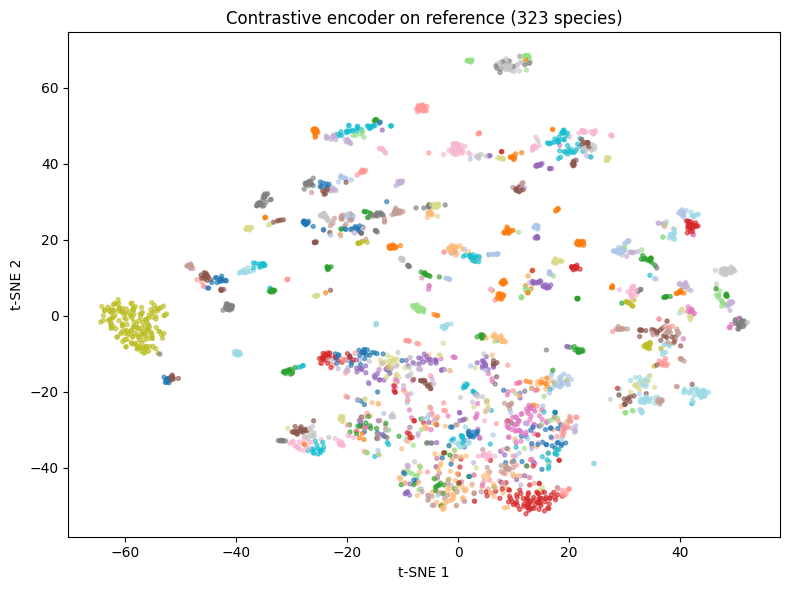

In [42]:
# Visualize contrastive embeddings on reference data (before VAE)
import csv
from sklearn.manifold import TSNE

eval_seqs, eval_labels_str = [], []
with open(EVAL_TSV) as f:
    reader = csv.reader(f, delimiter='\t')
    next(reader)
    for row in reader:
        eval_seqs.append(row[0])
        eval_labels_str.append(row[1])

unique_labels = sorted(set(eval_labels_str))
lab2id = {l: i for i, l in enumerate(unique_labels)}
eval_labels = np.array([lab2id[l] for l in eval_labels_str])

# Extract k-mers and embed
eval_kmer_np = kmer_extractor.extract_batch(eval_seqs, verbose=True)
with torch.no_grad():
    pretrain_emb = pretrain_model.encoder(
        torch.from_numpy(eval_kmer_np.astype(np.float32)).to(DEVICE)
    ).cpu().numpy()

n_vis = min(3000, len(eval_seqs))
idx_vis = np.random.RandomState(SEED).choice(len(eval_seqs), n_vis, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
emb_2d = tsne.fit_transform(pretrain_emb[idx_vis])

plt.figure(figsize=(8, 6))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=eval_labels[idx_vis], cmap='tab20', s=8, alpha=0.6)
plt.title(f'Contrastive encoder on reference ({len(unique_labels)} species)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

In [43]:
# Linear probe on contrastive embeddings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split as tts

probe_train_idx, probe_test_idx = tts(
    np.arange(len(eval_labels)), test_size=0.5,
    stratify=eval_labels, random_state=SEED,
)

X_train = pretrain_emb[probe_train_idx]
X_test = pretrain_emb[probe_test_idx]
y_train = eval_labels[probe_train_idx]
y_test = eval_labels[probe_test_idx]

lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
probe_acc = accuracy_score(y_test, y_pred)
probe_f1 = f1_score(y_test, y_pred, average='macro')

print(f'Linear probe on contrastive embeddings ({X_train.shape[1]}-dim):')
print(f'  Train: {len(y_train)} | Test: {len(y_test)} | Classes: {len(unique_labels)}')
print(f'  Accuracy: {probe_acc:.4f}')
print(f'  Macro F1: {probe_f1:.4f}')

Linear probe on contrastive embeddings (16-dim):
  Train: 18639 | Test: 18639 | Classes: 323
  Accuracy: 0.7228
  Macro F1: 0.6539


## 4. Create model and load pretrained encoder

In [44]:
model = KmerDPVAE(
    k=K,
    d_z=D_Z,
    h_dim=H_DIM,
    K_max=K_MAX,
    alpha=ALPHA,
    device=DEVICE,
    seed=SEED,
)

# Load contrastive pretrained weights into encoder backbone
model.encoder.load_contrastive_weights(pretrain_model)

# Freeze encoder backbone (only train decoder + variance head)
for param in model.encoder.linear1.parameters():
    param.requires_grad = False
for param in model.encoder.batch1.parameters():
    param.requires_grad = False
for param in model.encoder.linear2.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total:,}')
print(f'Trainable parameters: {trainable:,} (encoder frozen)')
print(f'Latent dim: {D_Z}')
print(f'DP-GMM components: {K_MAX}')

Total parameters: 219,168
Trainable parameters: 78,352 (encoder frozen)
Latent dim: 16
DP-GMM components: 500


## 5. Phase 1: Warm-up (decoder + variance head only)

Train with a simple Gaussian prior. The loss is:

$$\mathcal{L}_{\text{warm}} = \text{MSE}(\hat{f}, f) + \beta \cdot \text{KL}\big[q_\phi(z|x) \,\|\, \mathcal{N}(0, I)\big]$$

where $\text{KL} = \frac{1}{2}\sum_d \big(\sigma_d^2 + \mu_d^2 - 1 - \log \sigma_d^2\big)$ and $\beta$ linearly anneals from $0 \to 1$ over `KL_ANNEAL_EPOCHS`.

The diagnostic checks whether $z=0$ gives much worse reconstruction — a ratio $\gg 1$ confirms the decoder uses $z$.

In [45]:
warm_losses = warmup_phase(
    model, kmer_tensor,
    epochs=WARM_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    device=DEVICE, kl_anneal_epochs=KL_ANNEAL_EPOCHS,
)

=== Phase 1: Warm-up (1000 epochs) ===
  Epoch 10/1000  loss=617.1065  beta=0.333
  Epoch 20/1000  loss=295.0615  beta=0.667
  Epoch 30/1000  loss=240.9400  beta=1.000
  Epoch 40/1000  loss=216.9980  beta=1.000
  Epoch 50/1000  loss=202.5807  beta=1.000
  Epoch 60/1000  loss=194.0555  beta=1.000
  Epoch 70/1000  loss=188.9177  beta=1.000
  Epoch 80/1000  loss=185.9707  beta=1.000
  Epoch 90/1000  loss=183.2556  beta=1.000
  Epoch 100/1000  loss=181.3044  beta=1.000
  Epoch 110/1000  loss=180.0402  beta=1.000
  Epoch 120/1000  loss=178.7745  beta=1.000
  Epoch 130/1000  loss=176.9068  beta=1.000
  Epoch 140/1000  loss=175.6682  beta=1.000
  Epoch 150/1000  loss=175.4027  beta=1.000
  Epoch 160/1000  loss=175.1932  beta=1.000
  Epoch 170/1000  loss=173.9974  beta=1.000
  Epoch 180/1000  loss=173.1635  beta=1.000
  Epoch 190/1000  loss=172.4173  beta=1.000
  Epoch 200/1000  loss=172.3877  beta=1.000
  Epoch 210/1000  loss=171.8921  beta=1.000
  Epoch 220/1000  loss=170.4891  beta=1.000
  

Recon loss (with z): 150.5380
Recon loss (z=0):    558.2701
Ratio z=0 / with_z:  3.71x worse


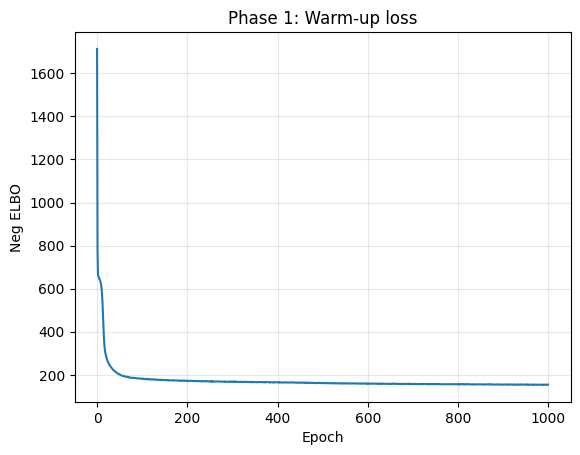

In [46]:
# Post warm-up diagnostic: is the decoder using z?
model.eval()
with torch.no_grad():
    batch = kmer_tensor[:64].to(DEVICE)
    z, mu, sigma2 = model.encoder(batch)
    pred_with_z = model.decoder(z)
    pred_no_z = model.decoder(torch.zeros_like(z))
    recon_with_z = model.reconstruction_loss(pred_with_z, batch)
    recon_no_z = model.reconstruction_loss(pred_no_z, batch)
print(f"Recon loss (with z): {recon_with_z.item():.4f}")
print(f"Recon loss (z=0):    {recon_no_z.item():.4f}")
print(f"Ratio z=0 / with_z:  {recon_no_z.item() / max(recon_with_z.item(), 1e-8):.2f}x worse")

plt.plot(warm_losses)
plt.title('Phase 1: Warm-up loss')
plt.xlabel('Epoch')
plt.ylabel('Neg ELBO')
plt.grid(True, alpha=0.3)
plt.show()

## 6. Phase 2: Initialize DP-GMM

Collect all encoder means $\mu_i$ and run k-means to initialize the $K_{\max}$ component centers $m_k$. Component variances are set to the global variance: $S_k = \text{diag}(\text{Var}(\mu))$. Stick-breaking parameters are reset: $a_k = 1,\; b_k = \alpha$.

In [47]:
init_dpgmm_phase(model, kmer_tensor, batch_size=BATCH_SIZE, device=DEVICE)

=== Phase 2: Initialized 500 components from 40000 samples ===


## 7. Phase 3: Joint training

Minimize the negative ELBO with DP-GMM prior plus an overlap penalty:

$$-\mathcal{L} = \underbrace{\text{MSE}(\hat{f}, f)}_{\text{recon}} - \frac{1}{B}\Big(\underbrace{\sum_{i,k} r_{ik} \,\mathbb{E}[\log \mathcal{N}(z_i | m_k, S_k)]}_{\text{comp\_ll}} + \underbrace{\sum_{i,k} r_{ik}\,\mathbb{E}[\log \pi_k]}_{\text{stick}} + \underbrace{H[q(z|x)]}_{\text{H\_post}} + \underbrace{H[q(c)]}_{\text{H\_assign}} - \underbrace{\text{KL}[q(v)\|p(v)]}_{\text{kl\_stick}}\Big) + \underbrace{\lambda \sum_{k<l} \pi_k \pi_l \exp(-D_B(k,l))}_{\text{overlap}}$$

where $D_B(k,l)$ is the Bhattacharyya distance between components $k$ and $l$.

Closed-form M-step updates every epoch:
- $m_k = \frac{1}{N_k}\sum_i r_{ik}\,\mu_i$
- $s_k^2 = \frac{1}{N_k}\sum_i r_{ik}\big[\sigma_i^2 + (\mu_i - m_k)^2\big]$
- $a_k = 1 + N_k, \quad b_k = \alpha + \sum_{j>k} N_j$

In [48]:
joint_history = joint_phase(
    model, kmer_tensor,
    epochs=JOINT_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
    device=DEVICE, mixture_update_interval=MIXTURE_UPDATE_INTERVAL,
    overlap_lambda=OVERLAP_LAMBDA,
    save_path=SAVE_PATH,
)

=== Phase 3: Joint training (2000 epochs, overlap_lambda=1.0) ===
  Epoch 10/2000  elbo=161.41  recon=123.93  comp_ll=-3.16  stick=-4.84  H_post=-11.72  H_assign=0.90  kl_stick=1192.90  overlap=0.0164
  Epoch 20/2000  elbo=167.49  recon=124.42  comp_ll=-2.70  stick=-5.00  H_post=-11.79  H_assign=0.88  kl_stick=1564.19  overlap=0.0140
  Epoch 30/2000  elbo=169.51  recon=124.06  comp_ll=-2.53  stick=-5.04  H_post=-11.85  H_assign=0.85  kl_stick=1718.70  overlap=0.0129
  Epoch 40/2000  elbo=170.17  recon=123.33  comp_ll=-2.43  stick=-5.08  H_post=-11.89  H_assign=0.84  kl_stick=1808.57  overlap=0.0122
  Epoch 50/2000  elbo=171.68  recon=123.73  comp_ll=-2.44  stick=-5.10  H_post=-11.94  H_assign=0.85  kl_stick=1875.51  overlap=0.0124
  Epoch 60/2000  elbo=171.89  recon=123.26  comp_ll=-2.46  stick=-5.07  H_post=-11.94  H_assign=0.82  kl_stick=1917.51  overlap=0.0118
  Epoch 70/2000  elbo=171.75  recon=123.34  comp_ll=-2.50  stick=-5.07  H_post=-11.93  H_assign=0.82  kl_stick=1902.03  over

## 8. Training curves

The 9 plots show how each ELBO component evolves during joint training:
- **Neg ELBO**: total loss being minimized (should decrease)
- **Recon loss**: MSE reconstruction quality (should decrease)
- **Component LL**: how well embeddings fit their assigned components (should become less negative)
- **Overlap**: Bhattacharyya overlap between components (should decrease = better separation)
- **E[log π]**: expected log mixture weights (should stabilize)
- **H[q(z)]**: posterior entropy — if it grows unboundedly, the variance is exploding
- **H[q(c)]**: assignment entropy — low = confident assignments
- **KL stick**: cost of deviating from the DP prior — if it explodes, too many active components

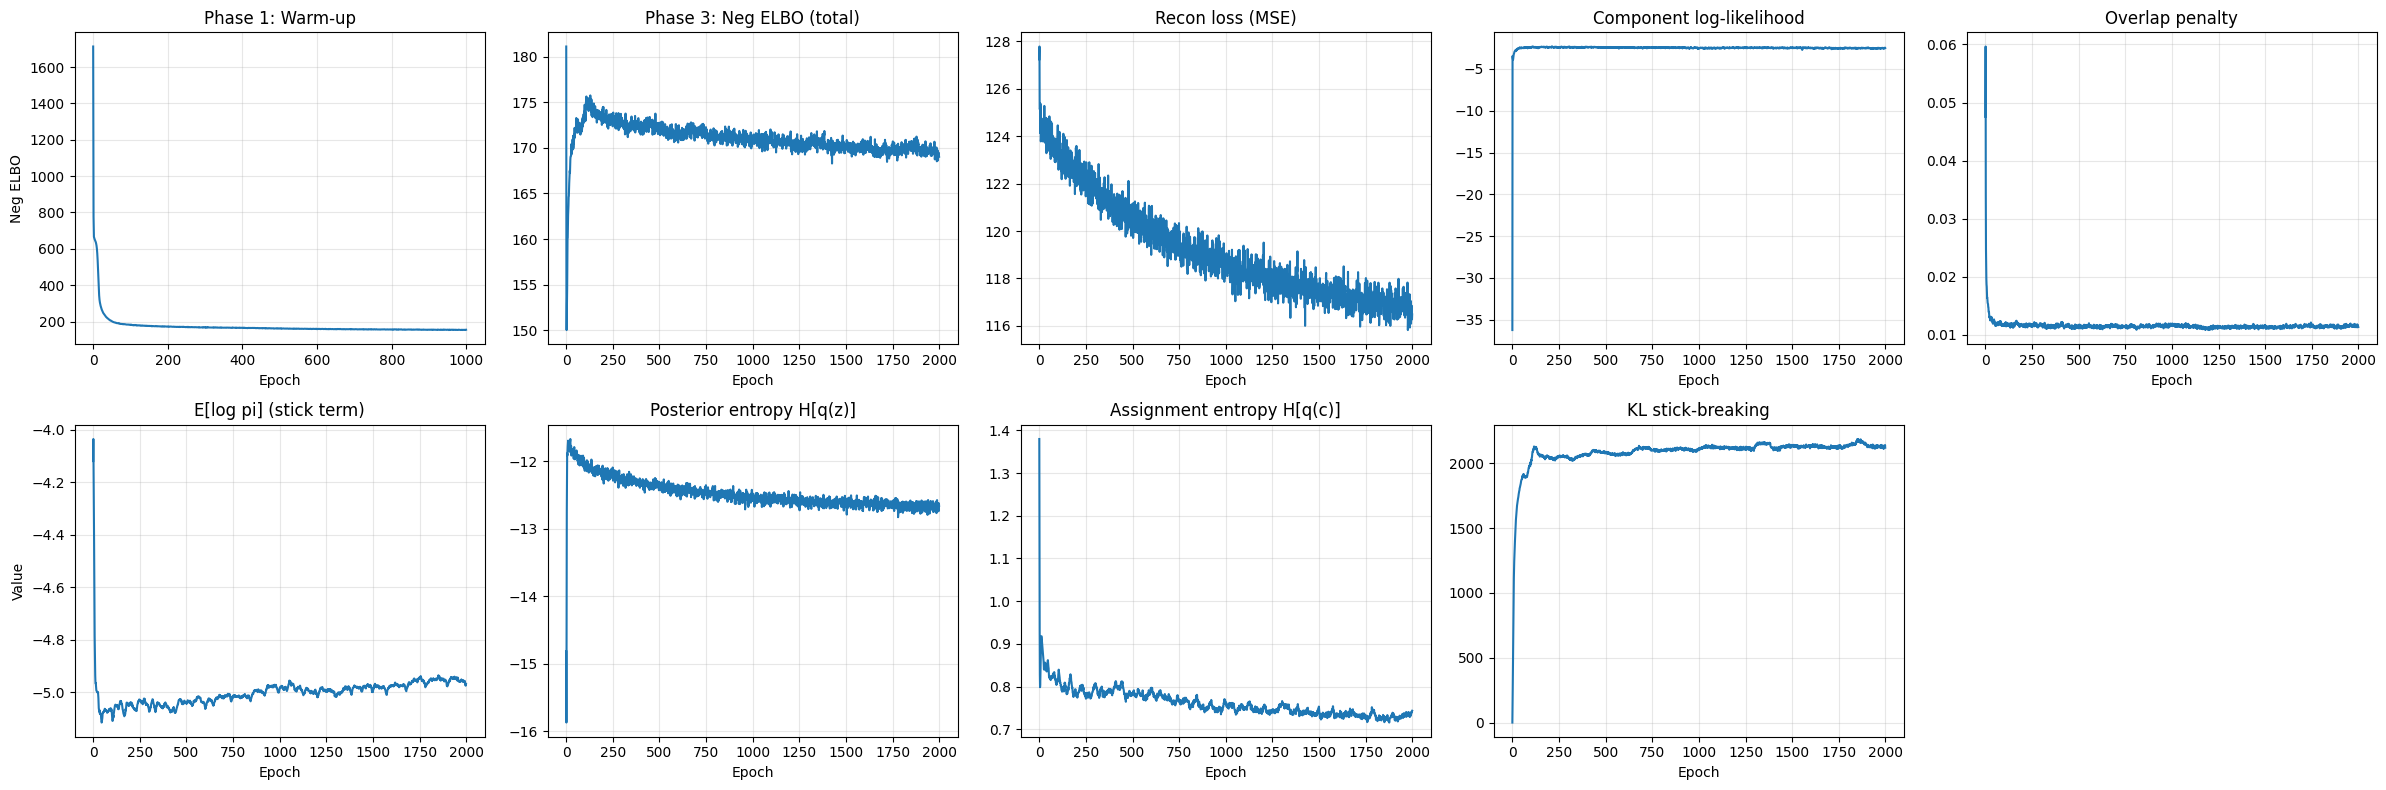

In [49]:
fig, axes = plt.subplots(2, 5, figsize=(24, 8))

axes[0, 0].plot(warm_losses)
axes[0, 0].set_title('Phase 1: Warm-up')
axes[0, 0].set_ylabel('Neg ELBO')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(joint_history['neg_elbo'])
axes[0, 1].set_title('Phase 3: Neg ELBO (total)')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(joint_history['recon_loss'])
axes[0, 2].set_title('Recon loss (MSE)')
axes[0, 2].grid(True, alpha=0.3)

axes[0, 3].plot(joint_history['component_ll'])
axes[0, 3].set_title('Component log-likelihood')
axes[0, 3].grid(True, alpha=0.3)

axes[0, 4].plot(joint_history['overlap'])
axes[0, 4].set_title('Overlap penalty')
axes[0, 4].grid(True, alpha=0.3)

axes[1, 0].plot(joint_history['stick_term'])
axes[1, 0].set_title('E[log pi] (stick term)')
axes[1, 0].set_ylabel('Value')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(joint_history['posterior_entropy'])
axes[1, 1].set_title('Posterior entropy H[q(z)]')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(joint_history['assignment_entropy'])
axes[1, 2].set_title('Assignment entropy H[q(c)]')
axes[1, 2].grid(True, alpha=0.3)

axes[1, 3].plot(joint_history['stick_kl'])
axes[1, 3].set_title('KL stick-breaking')
axes[1, 3].grid(True, alpha=0.3)

axes[1, 4].axis('off')

for ax in axes.flat:
    if ax.has_data():
        ax.set_xlabel('Epoch')

plt.tight_layout()
plt.show()

## 9. Evaluate on Reference dataset

Load `reference/binning_5.tsv`, encode, cluster via DP-GMM responsibilities $r_{ik} = q(c_i = k)$, and evaluate:

- **ARI**: Adjusted Rand Index — agreement corrected for chance, range $[-1, 1]$
- **NMI**: Normalized Mutual Information — shared information, range $[0, 1]$  
- **ACC**: Clustering accuracy via Hungarian matching — optimal 1-to-1 mapping between clusters and species

Three uncertainty sources visualized on t-SNE:
1. **Embedding uncertainty**: $\text{Tr}(\Sigma_i) = \sum_d \sigma_{id}^2$ — total posterior variance
2. **Assignment entropy**: $H(c_i | x_i) = -\sum_k r_{ik} \log r_{ik}$ — how spread the cluster assignment is
3. **Max cluster probability**: $\max_k r_{ik}$ — confidence of the best assignment

In [50]:
import csv
from torch.utils.data import DataLoader, TensorDataset
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from evaluation.eval_utils import align_labels_via_hungarian_algorithm

# Load reference dataset
eval_seqs, eval_labels_str = [], []
with open(EVAL_TSV) as f:
    reader = csv.reader(f, delimiter='\t')
    next(reader)
    for row in reader:
        eval_seqs.append(row[0])
        eval_labels_str.append(row[1])

unique_labels = sorted(set(eval_labels_str))
lab2id = {l: i for i, l in enumerate(unique_labels)}
eval_labels = np.array([lab2id[l] for l in eval_labels_str])

eval_kmer = torch.from_numpy(
    kmer_extractor.extract_batch(eval_seqs, verbose=True).astype(np.float32)
)

print(f'\nEval: {len(eval_seqs)} sequences, {len(unique_labels)} species')
print(f'K-mer shape: {eval_kmer.shape}')

 Extracting k-mer profiles │██████████████████████████████│ 37278/37278 [02:01<00:00]


Eval: 37278 sequences, 323 species
K-mer shape: torch.Size([37278, 256])


In [51]:
# Encode eval data
model.eval()
eval_loader = DataLoader(TensorDataset(eval_kmer), batch_size=BATCH_SIZE, shuffle=False)

eval_mu, eval_sigma2 = [], []
with torch.no_grad():
    for (batch,) in eval_loader:
        batch = batch.to(DEVICE)
        _, mu, sigma2 = model.encoder(batch)
        eval_mu.append(mu.cpu())
        eval_sigma2.append(sigma2.cpu())

eval_mu = torch.cat(eval_mu)
eval_sigma2 = torch.cat(eval_sigma2)

# Cluster assignments
r_eval = model.dpgmm.compute_responsibilities(eval_mu.to(DEVICE), eval_sigma2.to(DEVICE))
eval_assignments = r_eval.argmax(dim=1).cpu().numpy()
eval_U = eval_sigma2.sum(dim=1).numpy()

# Metrics
ari = adjusted_rand_score(eval_labels, eval_assignments)
nmi = normalized_mutual_info_score(eval_labels, eval_assignments)
label_map = align_labels_via_hungarian_algorithm(eval_labels, eval_assignments)
aligned = np.array([label_map.get(p, -1) for p in eval_assignments])
acc = (aligned == eval_labels).mean()

print(f'ARI={ari:.4f}  NMI={nmi:.4f}  ACC={acc:.4f}')
print(f'Clusters used: {len(set(eval_assignments))} / {K_MAX}')
print(f'True species: {len(unique_labels)}')

ARI=0.1844  NMI=0.7039  ACC=0.3307
Clusters used: 289 / 500
True species: 323


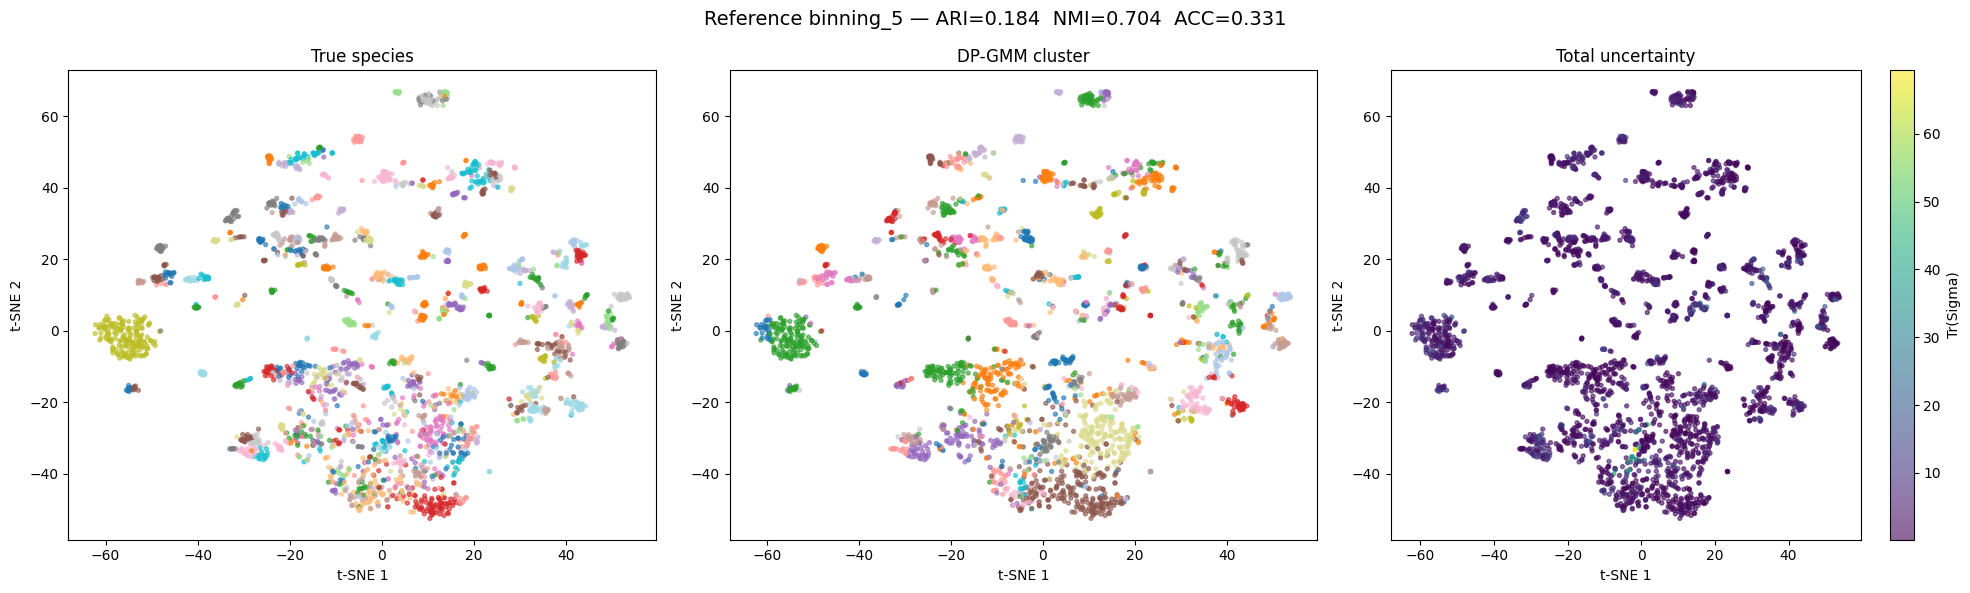

In [52]:
# t-SNE visualization on reference data
n_vis = min(3000, eval_mu.shape[0])
idx_vis = np.random.RandomState(SEED).choice(eval_mu.shape[0], n_vis, replace=False)

mu_vis = eval_mu[idx_vis].numpy()
assign_vis = eval_assignments[idx_vis]
labels_vis = eval_labels[idx_vis]
U_vis = eval_U[idx_vis]

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
emb_2d = tsne.fit_transform(mu_vis)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels_vis, cmap='tab20', s=8, alpha=0.6)
axes[0].set_title('True species')

axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=assign_vis, cmap='tab20', s=8, alpha=0.6)
axes[1].set_title('DP-GMM cluster')

sc = axes[2].scatter(emb_2d[:, 0], emb_2d[:, 1], c=U_vis, cmap='viridis', s=8, alpha=0.6)
axes[2].set_title('Total uncertainty')
plt.colorbar(sc, ax=axes[2], label='Tr(Sigma)')

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.suptitle(f'Reference binning_5 — ARI={ari:.3f}  NMI={nmi:.3f}  ACC={acc:.3f}', fontsize=14)
plt.tight_layout()
plt.show()

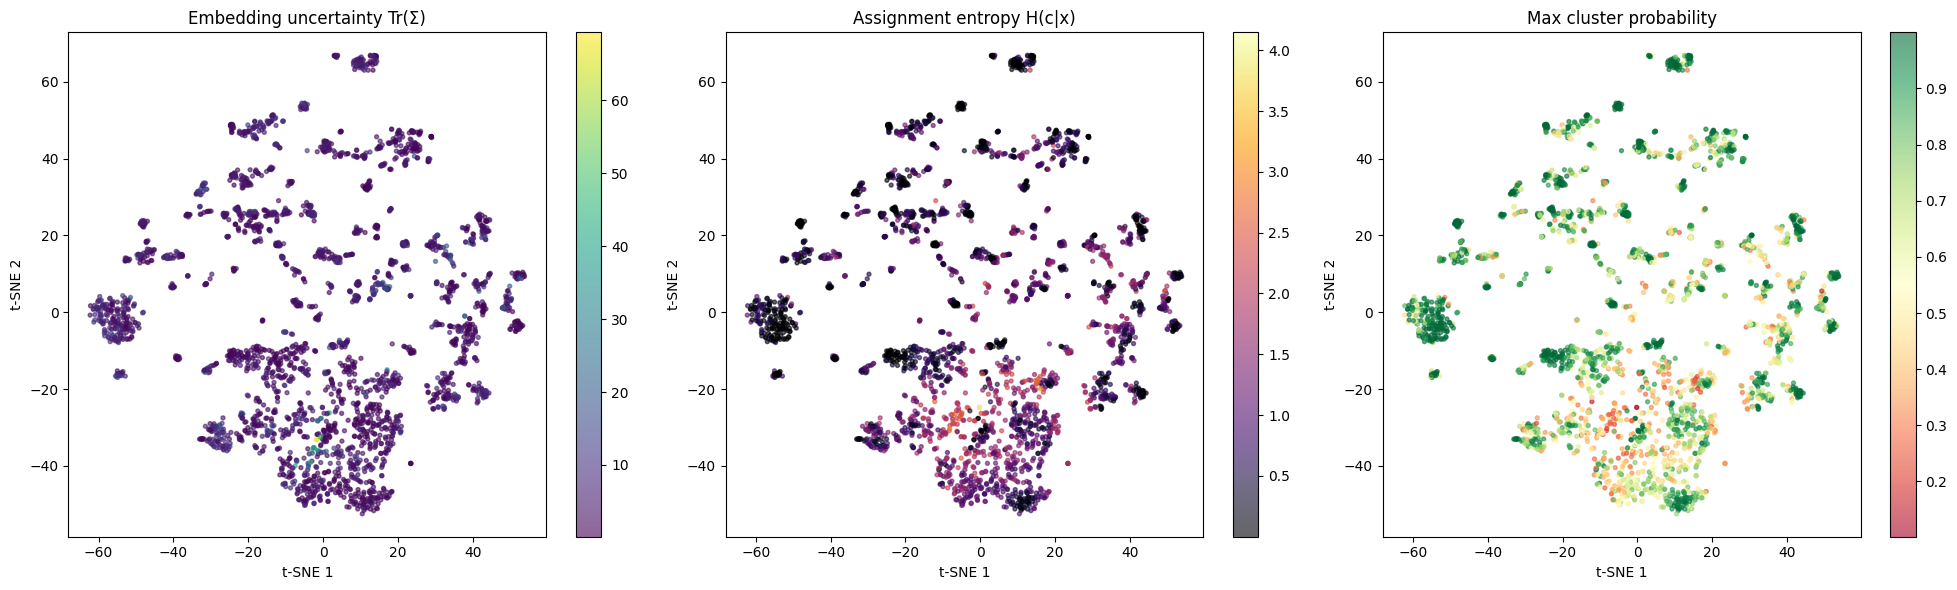

In [53]:
# Uncertainty decomposition on reference data
# 1. Embedding uncertainty: Tr(Sigma) from encoder posterior
# 2. Assignment entropy: H(c|x) = -sum r_ik log r_ik
# 3. Max cluster probability: max_k r_ik (confidence)

H_assign = -(r_eval * torch.log(r_eval.clamp(min=1e-30))).sum(dim=1).cpu().numpy()
max_prob = r_eval.max(dim=1).values.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sc0 = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=eval_U[idx_vis], cmap='viridis', s=8, alpha=0.6)
axes[0].set_title('Embedding uncertainty Tr(Σ)')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=H_assign[idx_vis], cmap='inferno', s=8, alpha=0.6)
axes[1].set_title('Assignment entropy H(c|x)')
plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(emb_2d[:, 0], emb_2d[:, 1], c=max_prob[idx_vis], cmap='RdYlGn', s=8, alpha=0.6)
axes[2].set_title('Max cluster probability')
plt.colorbar(sc2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

In [ ]:
# Per-bin accuracy vs uncertainty threshold
# For each bin, compute accuracy of points within that uncertainty range
aligned_eval = np.array([label_map.get(p, -1) for p in eval_assignments])
correct = (aligned_eval == eval_labels).astype(float)

measures = {
    'Embedding Tr(Σ)': eval_U,
    'Assignment entropy H(c|x)': H_assign,
    'Max cluster prob': max_prob,
}

from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, vals) in zip(axes, measures.items()):
    n_bins = 20
    bin_edges = np.percentile(vals, np.linspace(0, 100, n_bins + 1))
    bin_edges[-1] += 1e-10
    bin_idx = np.digitize(vals, bin_edges) - 1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    bin_centers, bin_acc, bin_counts = [], [], []
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.sum() > 0:
            bin_centers.append(vals[mask].mean())
            bin_acc.append(correct[mask].mean())
            bin_counts.append(mask.sum())

    bin_centers = np.array(bin_centers)
    bin_acc = np.array(bin_acc)
    bin_counts = np.array(bin_counts)

    sizes = 30 + 200 * bin_counts / bin_counts.max()
    ax.scatter(bin_centers, bin_acc, s=sizes, alpha=0.7, edgecolors='k', linewidths=0.5)

    rho, pval = spearmanr(vals, correct)
    ax.set_title(f'{name}\nSpearman ρ={rho:.3f} (p={pval:.1e})')
    ax.set_xlabel(name)
    ax.set_ylabel('Accuracy (per bin)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.axhline(correct.mean(), color='gray', ls='--', lw=1, label=f'Overall ACC={correct.mean():.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Per-bin accuracy vs uncertainty (quantile-binned, bubble size ∝ count)', fontsize=13)
plt.tight_layout()
plt.show()

### Accuracy vs Coverage

Sort samples by uncertainty (most certain first), then compute cumulative accuracy as we remove uncertain points. A good uncertainty measure yields increasing accuracy as coverage decreases (curve rises toward the right).

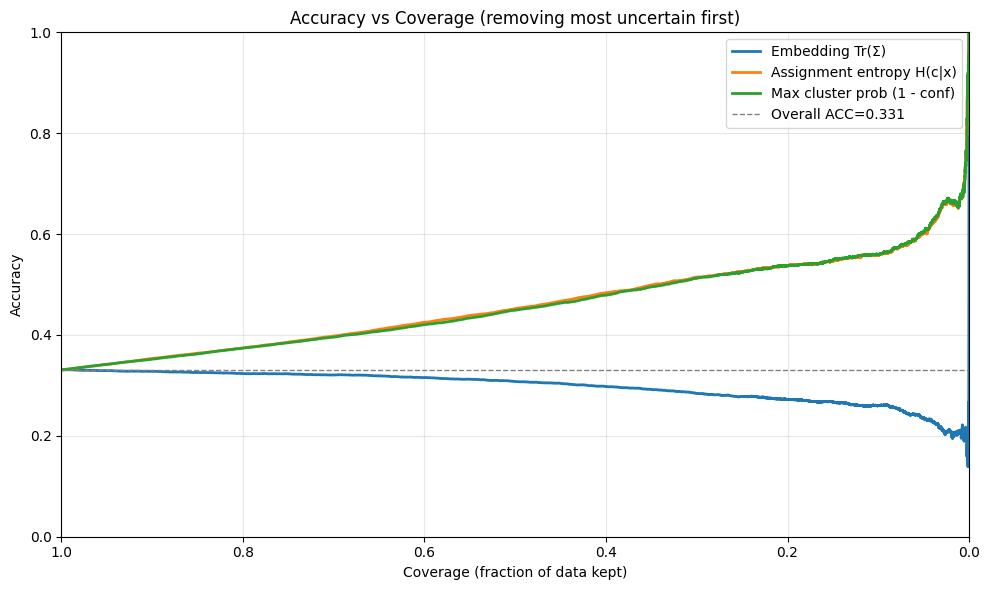

In [54]:
# Accuracy vs coverage for each uncertainty measure
# Sort by uncertainty (least uncertain first), remove most uncertain progressively

aligned = np.array([label_map.get(p, -1) for p in eval_assignments])
correct = aligned == eval_labels

measures = {
    'Embedding Tr(Σ)': eval_U,
    'Assignment entropy H(c|x)': H_assign,
    'Max cluster prob (1 - conf)': 1.0 - max_prob,
}

fig, ax = plt.subplots(figsize=(10, 6))

for name, uncertainty in measures.items():
    # Sort: most uncertain first (descending uncertainty)
    order = np.argsort(-uncertainty)
    sorted_correct = correct[order]
    
    # Cumulative accuracy as we remove most uncertain points
    cum_correct = np.cumsum(sorted_correct[::-1])[::-1]
    n = np.arange(len(sorted_correct), 0, -1)
    cum_acc = cum_correct / n
    coverage = n / len(sorted_correct)
    
    ax.plot(coverage, cum_acc, lw=2, label=name)

ax.axhline(correct.mean(), color='gray', ls='--', lw=1, label=f'Overall ACC={correct.mean():.3f}')
ax.set_xlabel('Coverage (fraction of data kept)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Coverage (removing most uncertain first)')
ax.set_xlim(1, 0)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What does embedding variance Tr(Σ) capture?

Check if Tr(Σ) correlates with sequence-level properties: composition rarity (L2 distance to mean k-mer profile) and k-mer sparsity (fraction of zero 4-mers).

## Uncertainty validation: real clusters + real boundaries + synthetic outliers

Use the DP-GMM's own structure to define three categories:
- **Core**: real sequences with $\max_k r_{ik} > 0.9$ (confident assignment)
- **Boundary**: real sequences where $r_{i,\text{top1}} / r_{i,\text{top2}} < 2$ (ambiguous, two clusters compete)
- **Outliers**: synthetic k-mer profiles sampled from $\text{Exp}(3\bar{f})$ — far from real data distribution

Expected behavior if uncertainty is calibrated:

| Type | $\text{Tr}(\Sigma)$ | $H(c\|x)$ | $\max_k r_{ik}$ |
|------|---------------------|-----------|-----------------|
| Core | Low | Low | High |
| Boundary | Medium | High | Low |
| Outlier | High | High | Low |

### Variance response to k-mer augmentation

Take 1000 real k-mer profiles $f_i$ and apply increasing perturbations at levels $\ell \in [0, 1]$:

1. **Gaussian noise**: $\tilde{f} = \max(f + \mathcal{N}(0, \ell \cdot \bar{f}), \; 0)$
2. **Dropout**: $\tilde{f}_d = f_d \cdot \mathbb{1}[u_d > \ell], \quad u_d \sim \text{Uniform}(0,1)$
3. **Scaling**: $\tilde{f} = f \cdot s, \quad s \sim \text{Uniform}(1-\ell, 1+\ell)$

If $\text{Tr}(\Sigma)$ is calibrated, it should increase monotonically with $\ell$.

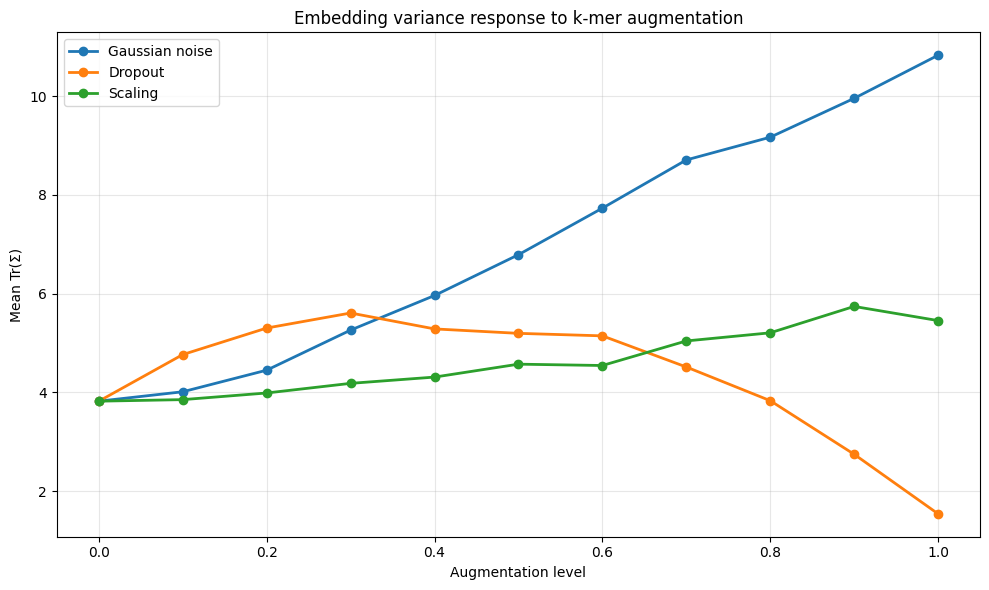

In [55]:
# Variance response to augmentation
rng_aug = np.random.RandomState(SEED)
base_kmer = eval_kmer[:1000].numpy()

noise_levels = np.linspace(0, 1, 11)
mean_count = base_kmer.mean()

results = {'Gaussian noise': [], 'Dropout': [], 'Scaling': []}

model.eval()
for level in noise_levels:
    augmented = {}

    gauss = base_kmer + rng_aug.normal(0, level * mean_count, size=base_kmer.shape)
    augmented['Gaussian noise'] = np.maximum(gauss, 0).astype(np.float32)

    drop_mask = rng_aug.random(base_kmer.shape) > level
    augmented['Dropout'] = (base_kmer * drop_mask).astype(np.float32)

    scale_factors = rng_aug.uniform(1 - level, 1 + level, size=(len(base_kmer), 1))
    augmented['Scaling'] = (base_kmer * scale_factors).astype(np.float32)

    for name, aug_data in augmented.items():
        aug_tensor = torch.from_numpy(aug_data).to(DEVICE)
        with torch.no_grad():
            _, _, sigma2 = model.encoder(aug_tensor)
        mean_trace = sigma2.sum(dim=1).mean().item()
        results[name].append(mean_trace)

fig, ax = plt.subplots(figsize=(10, 6))
for name, traces in results.items():
    ax.plot(noise_levels, traces, 'o-', markersize=6, lw=2, label=name)

ax.set_xlabel('Augmentation level')
ax.set_ylabel('Mean Tr(Σ)')
ax.set_title('Embedding variance response to k-mer augmentation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

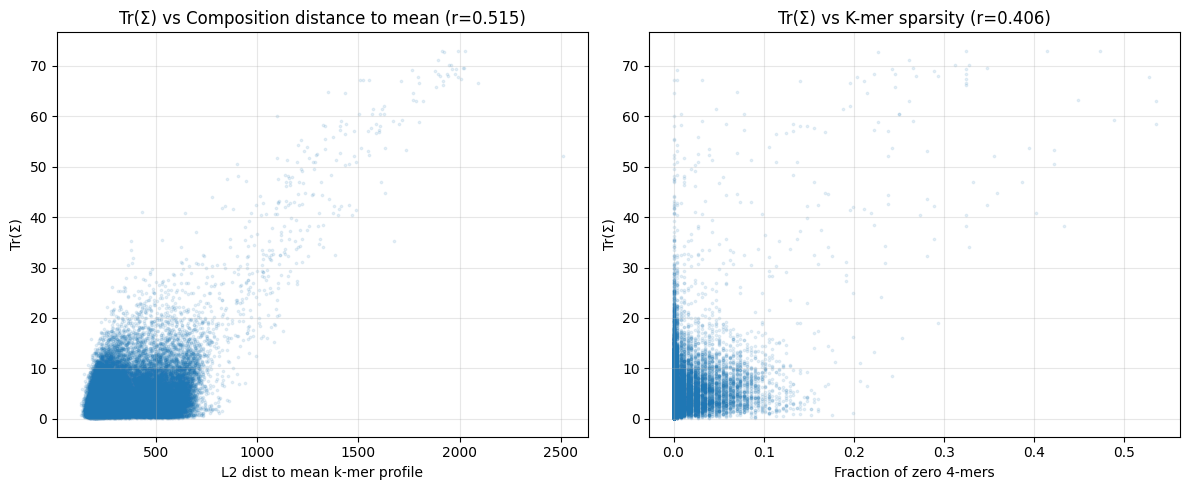

Correlations with Tr(Σ):
  Composition rarity: r = 0.515
  K-mer sparsity:     r = 0.406


In [56]:
# What does embedding variance capture?
eval_kmer_np = eval_kmer.numpy()

# Composition "rareness": distance to mean k-mer profile
mean_profile = eval_kmer_np.mean(axis=0)
composition_dist = np.sqrt(((eval_kmer_np - mean_profile) ** 2).sum(axis=1))

# Sparsity: fraction of zero k-mers
sparsity = (eval_kmer_np == 0).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(composition_dist, eval_U, alpha=0.1, s=3)
corr_rare = np.corrcoef(composition_dist, eval_U)[0, 1]
axes[0].set_title(f'Tr(Σ) vs Composition distance to mean (r={corr_rare:.3f})')
axes[0].set_xlabel('L2 dist to mean k-mer profile')
axes[0].set_ylabel('Tr(Σ)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(sparsity, eval_U, alpha=0.1, s=3)
corr_sparse = np.corrcoef(sparsity, eval_U)[0, 1]
axes[1].set_title(f'Tr(Σ) vs K-mer sparsity (r={corr_sparse:.3f})')
axes[1].set_xlabel('Fraction of zero 4-mers')
axes[1].set_ylabel('Tr(Σ)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Correlations with Tr(Σ):')
print(f'  Composition rarity: r = {corr_rare:.3f}')
print(f'  K-mer sparsity:     r = {corr_sparse:.3f}')

In [57]:
# Build the three categories from real + synthetic data
rng = np.random.RandomState(SEED)

# Already have eval_kmer, eval_mu, eval_sigma2, r_eval, eval_U from earlier cells
top2_probs = torch.topk(r_eval, k=2, dim=1).values.cpu().numpy()  # (N, 2)
max_prob_eval = top2_probs[:, 0]
ratio_top2 = top2_probs[:, 0] / top2_probs[:, 1].clip(min=1e-10)

# Cluster core: max_prob > 0.9
core_mask = max_prob_eval > 0.9
# Boundary: ratio of top-1 to top-2 responsibility < 2 (close competition)
boundary_mask = (~core_mask) & (ratio_top2 < 2.0)

# Subsample for balanced visualization
n_sample = min(500, core_mask.sum(), boundary_mask.sum())
core_idx = rng.choice(np.where(core_mask)[0], n_sample, replace=False)
n_boundary = min(n_sample, boundary_mask.sum())
boundary_idx = rng.choice(np.where(boundary_mask)[0], n_boundary, replace=False)

# Synthetic outliers: k-mer counts with 3x the mean magnitude
N_OUTLIERS = 200
mean_kmer = eval_kmer.numpy().mean()
outlier_kmer = torch.from_numpy(
    rng.exponential(scale=mean_kmer * 3, size=(N_OUTLIERS, 256)).astype(np.float32)
)

# Encode outliers
model.eval()
with torch.no_grad():
    _, out_mu, out_sigma2 = model.encoder(outlier_kmer.to(DEVICE))
out_mu = out_mu.cpu()
out_sigma2 = out_sigma2.cpu()
out_r = model.dpgmm.compute_responsibilities(out_mu.to(DEVICE), out_sigma2.to(DEVICE))
out_U = out_sigma2.sum(dim=1).numpy()
out_H = -(out_r * torch.log(out_r.clamp(min=1e-30))).sum(dim=1).cpu().numpy()
out_maxprob = out_r.max(dim=1).values.cpu().numpy()

# Combine all embeddings for t-SNE
all_mu_exp = torch.cat([eval_mu[core_idx], eval_mu[boundary_idx], out_mu])
all_types = (['core'] * len(core_idx) +
             ['boundary'] * len(boundary_idx) +
             ['outlier'] * N_OUTLIERS)
all_types = np.array(all_types)

all_U_exp = np.concatenate([eval_U[core_idx], eval_U[boundary_idx], out_U])
all_H_exp = np.concatenate([
    -(r_eval[core_idx] * torch.log(r_eval[core_idx].clamp(min=1e-30))).sum(dim=1).cpu().numpy(),
    -(r_eval[boundary_idx] * torch.log(r_eval[boundary_idx].clamp(min=1e-30))).sum(dim=1).cpu().numpy(),
    out_H,
])
all_maxprob_exp = np.concatenate([max_prob_eval[core_idx], max_prob_eval[boundary_idx], out_maxprob])

print(f'Core:     {len(core_idx)} (from {core_mask.sum()} available)')
print(f'Boundary: {len(boundary_idx)} (from {boundary_mask.sum()} available)')
print(f'Outliers: {N_OUTLIERS} (synthetic)')

Core:     500 (from 14306 available)
Boundary: 500 (from 8057 available)
Outliers: 200 (synthetic)


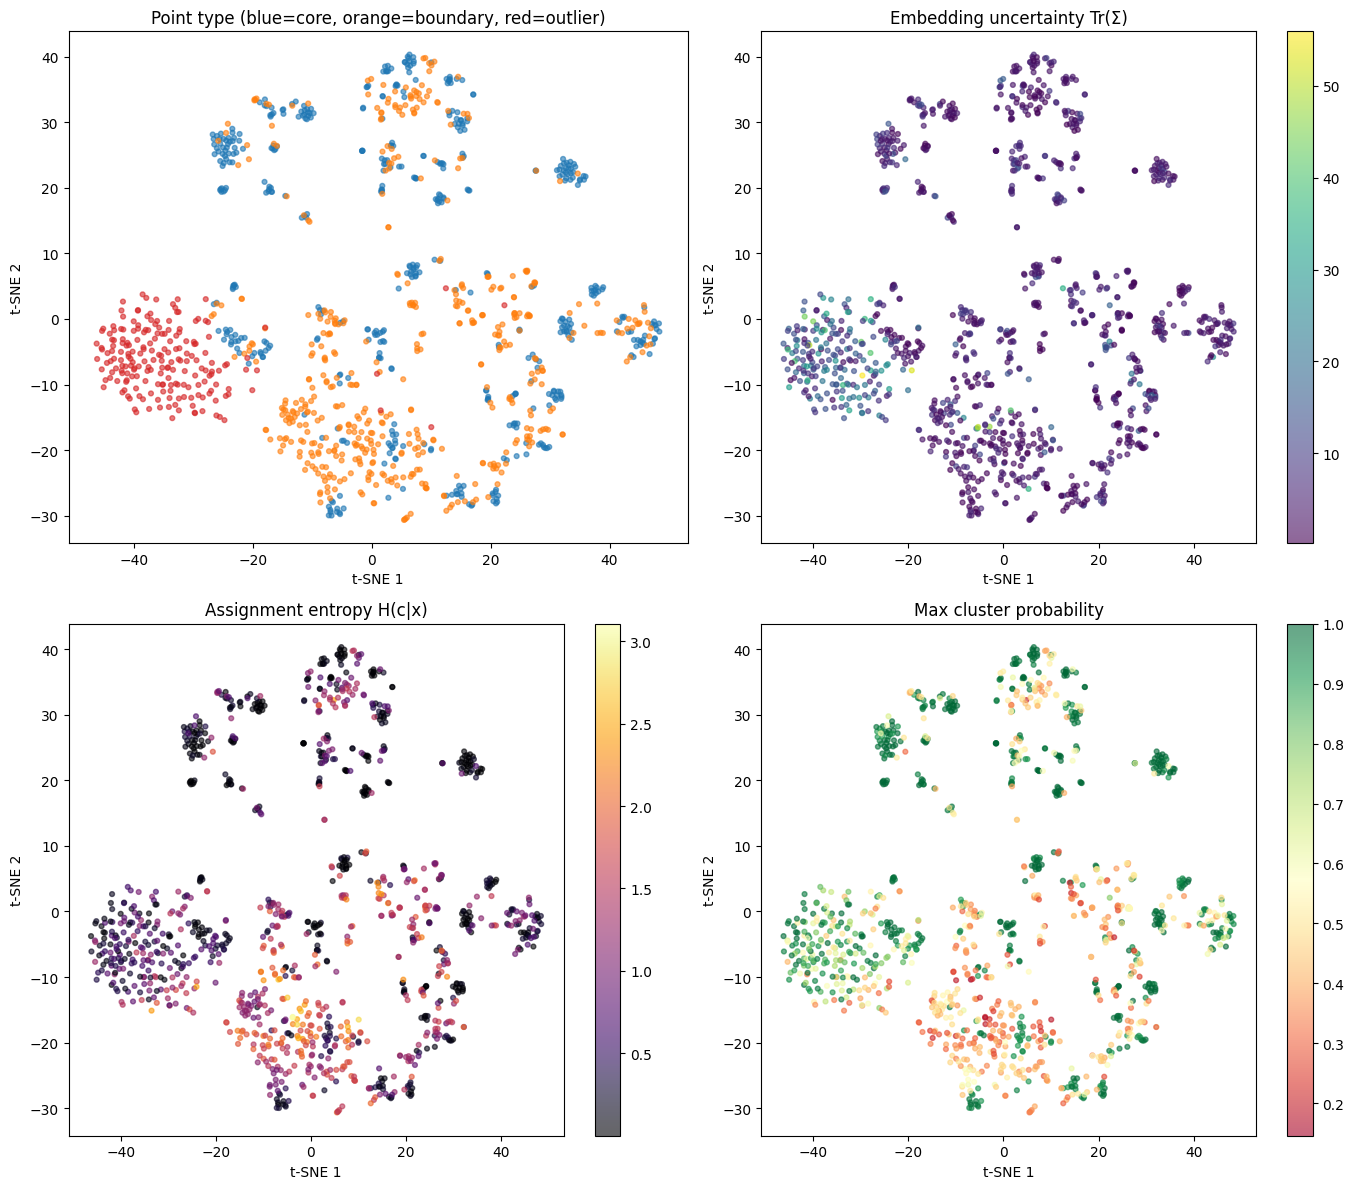


Type          Count      Tr(Σ)     H(c|x)   Max prob
--------------------------------------------------
core            500      4.616      0.129      0.974
boundary        500      4.552      1.428      0.432
outlier         200     16.549      0.686      0.753


In [58]:
# t-SNE + uncertainty visualization
tsne_exp = TSNE(n_components=2, perplexity=30, random_state=SEED)
exp_2d = tsne_exp.fit_transform(all_mu_exp.numpy())

type_colors = {'core': 'tab:blue', 'boundary': 'tab:orange', 'outlier': 'tab:red'}
type_c = [type_colors[t] for t in all_types]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Point types
axes[0, 0].scatter(exp_2d[:, 0], exp_2d[:, 1], c=type_c, s=12, alpha=0.6)
axes[0, 0].set_title('Point type (blue=core, orange=boundary, red=outlier)')

# Embedding uncertainty
sc1 = axes[0, 1].scatter(exp_2d[:, 0], exp_2d[:, 1], c=all_U_exp, cmap='viridis', s=12, alpha=0.6)
axes[0, 1].set_title('Embedding uncertainty Tr(Σ)')
plt.colorbar(sc1, ax=axes[0, 1])

# Assignment entropy
sc2 = axes[1, 0].scatter(exp_2d[:, 0], exp_2d[:, 1], c=all_H_exp, cmap='inferno', s=12, alpha=0.6)
axes[1, 0].set_title('Assignment entropy H(c|x)')
plt.colorbar(sc2, ax=axes[1, 0])

# Max cluster probability
sc3 = axes[1, 1].scatter(exp_2d[:, 0], exp_2d[:, 1], c=all_maxprob_exp, cmap='RdYlGn', s=12, alpha=0.6)
axes[1, 1].set_title('Max cluster probability')
plt.colorbar(sc3, ax=axes[1, 1])

for ax in axes.flat:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Type":<12} {"Count":>6} {"Tr(Σ)":>10} {"H(c|x)":>10} {"Max prob":>10}')
print('-' * 50)
for t in ['core', 'boundary', 'outlier']:
    mask = all_types == t
    print(f'{t:<12} {mask.sum():>6} {all_U_exp[mask].mean():>10.3f} '
          f'{all_H_exp[mask].mean():>10.3f} {all_maxprob_exp[mask].mean():>10.3f}')